# Customer Churn Prediction (Bank Customers)

## Introduction

Customer churn happens when customers stop using a bank’s services.  
Predicting churn helps banks understand customer behavior and take early actions to retain valuable customers.

In this project, we use data analysis and machine learning to study customer information and identify patterns related to churn.

## Problem Statement

The objective of this project is to build a machine learning model that predicts whether a customer will leave the bank.

Using the **Churn Modelling Dataset**, we will clean and prepare the data, perform exploratory data analysis, train a classification model, and evaluate its performance to understand the key factors that influence customer churn.

In [2]:
# import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [63]:
# load dataset
df = pd.read_csv('Customer-Churn-Records.csv')

In [64]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## Dataset Understanding

The **Bank Customer Churn Dataset** contains information about bank customers and their account activity. The dataset is used to analyze customer behavior and predict whether a customer will leave the bank.

Each row represents a customer, and each column represents a specific attribute such as credit score, geography, gender, age, account balance, and banking activity.

### Target Variable

- **Exited**
  - `1` → Customer left the bank (Churn)
  - `0` → Customer stayed with the bank

### Key Features

- **CreditScore** → Customer credit score  
- **Geography** → Customer's country  
- **Gender** → Male or Female  
- **Age** → Age of the customer  
- **Tenure** → Years the customer stayed with the bank  
- **Balance** → Bank account balance  
- **NumOfProducts** → Number of bank products used  
- **IsActiveMember** → Whether the customer is active  
- **EstimatedSalary** → Customer's estimated salary

This dataset helps identify patterns that influence customer churn and supports building a predictive machine learning model.

In [38]:
df.shape


(10000, 18)

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

In [40]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [65]:
# checking for missing values
df.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [42]:
# now checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [66]:
# drop unnecessary columns
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)


In [44]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [68]:
# Get a list of categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Get a list of numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11572\760838130.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [69]:
categorical_cols

Index(['Geography', 'Gender', 'Card Type'], dtype='str')

In [70]:
numerical_cols

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Point Earned'],
      dtype='str')

## Exploratory Data Analysis (EDA)

EDA helps us understand the distribution of features, relationships between variables, and patterns related to customer churn. We will explore both numerical and categorical features using visualizations.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11572\2270371878.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette='Set2')


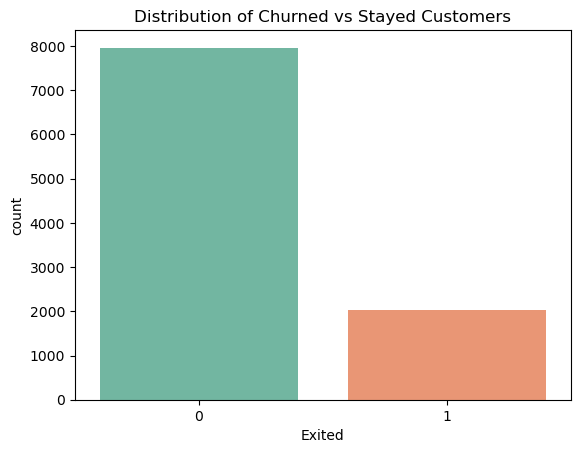

Exited
0    7962
1    2038
Name: count, dtype: int64


In [48]:
# Target distribution
sns.countplot(x='Exited', data=df, palette='Set2')
plt.title('Distribution of Churned vs Stayed Customers')
plt.show()

print(df['Exited'].value_counts())

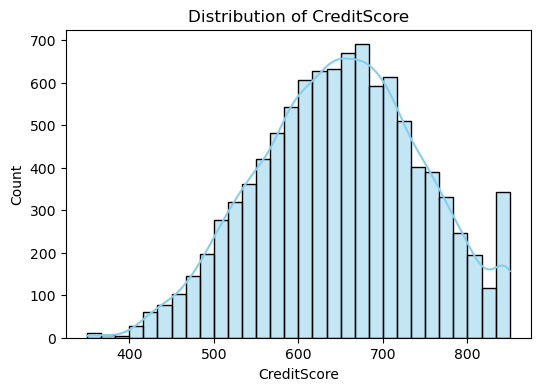

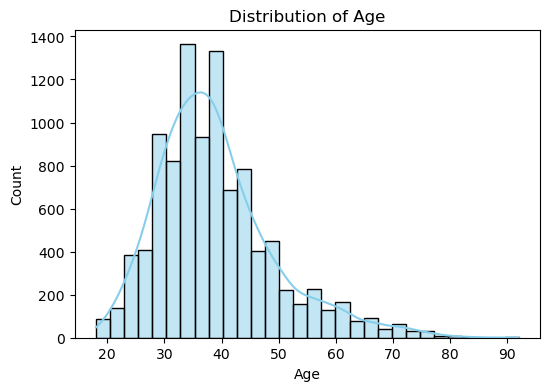

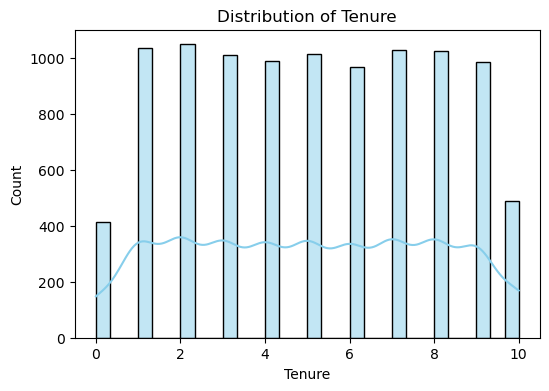

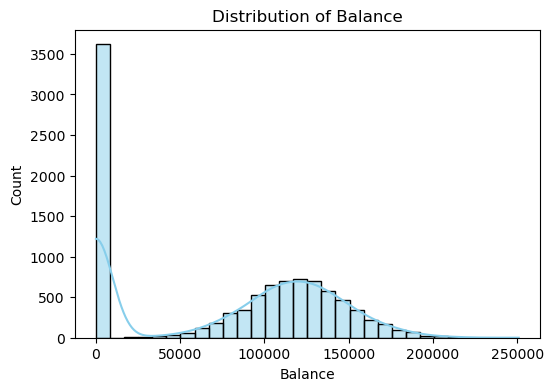

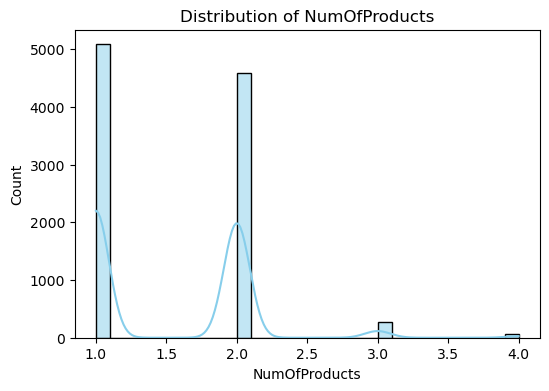

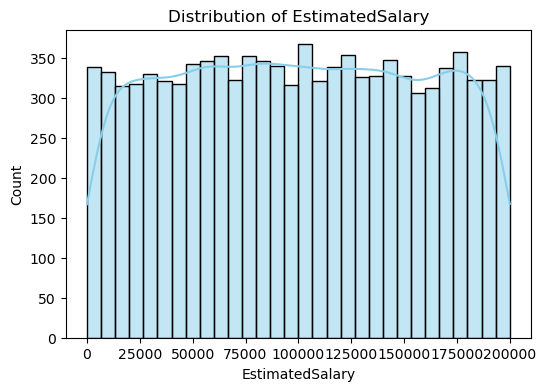

In [49]:
# Distribution of Numerical Features
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.show()

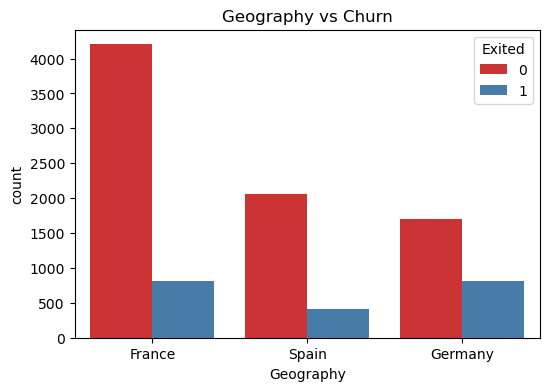

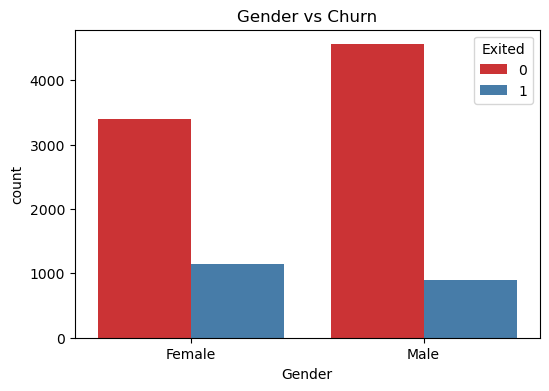

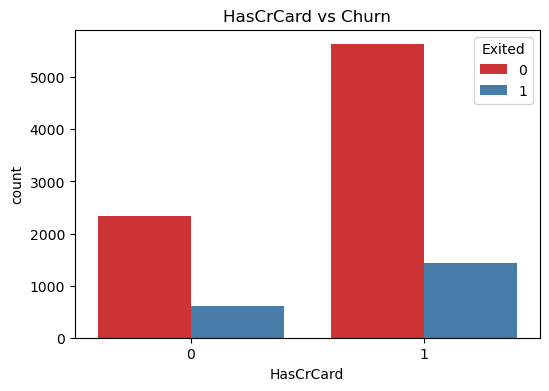

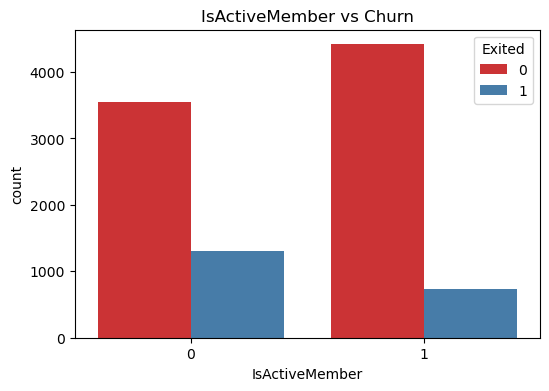

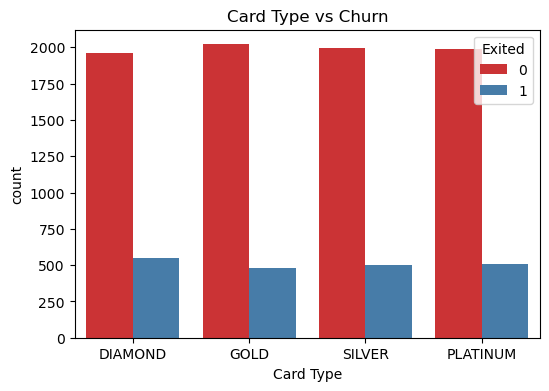

In [50]:
# Categorical Features vs Churn

categorical_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Card Type']

for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Exited', data=df, palette='Set1')
    plt.title(f'{col} vs Churn')
    plt.show()


In [51]:
categorical_cols

Index(['Geography', 'Gender', 'Card Type'], dtype='str')

In [71]:
# encode categorical features

# geography using one-hot encoding
df = pd.get_dummies(df, columns=['Geography'], prefix='Geo', drop_first=True)
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,Geo_Germany,Geo_Spain
0,619,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464,False,False
1,608,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456,False,True
2,502,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377,False,False
3,699,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350,False,False
4,850,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300,False,False
9996,516,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771,False,False
9997,709,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564,False,False
9998,772,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339,True,False


In [79]:
# Gender Column
df['Gender'] = df['Gender'].map({'Male' : 0 , 'Female' : 1})

In [72]:
# Card Type Column

df['Card Type'].value_counts()

Card Type
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64

In [76]:
df['Card Type'] = df['Card Type'].str.strip().str.upper()

mapping = {
    'SILVER': 1,
    'GOLD': 2,
    'PLATINUM': 3,
    'DIAMOND': 4
}

df['Card Type'] = df['Card Type'].replace(mapping)

In [77]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,Geo_Germany,Geo_Spain
0,619,Female,42,2,0.00,1,1,1,101348.88,1,1,2,4,464,False,False
1,608,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,4,456,False,True
2,502,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,4,377,False,False
3,699,Female,39,1,0.00,2,0,0,93826.63,0,0,5,2,350,False,False
4,850,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,2,425,False,True


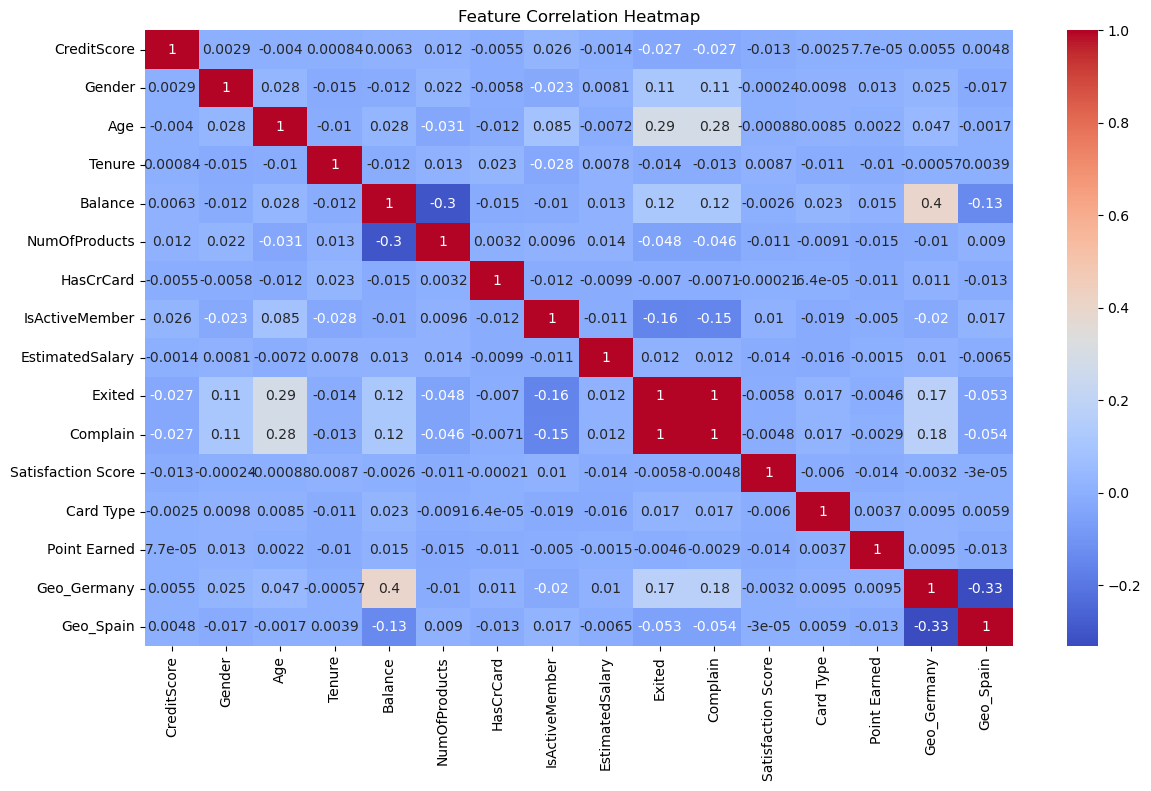

In [80]:
#Correlation Heatmap

plt.figure(figsize=(14,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()


In [81]:
# Since there is strong correlation of complain with Exited, so we will drop the column of complain
df.drop(columns=['Complain'], inplace=True)

In [82]:
df.head()    

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned,Geo_Germany,Geo_Spain
0,619,1,42,2,0.00,1,1,1,101348.88,1,2,4,464,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,0,3,4,456,False,True
2,502,1,42,8,159660.80,3,1,0,113931.57,1,3,4,377,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,0,5,2,350,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,0,5,2,425,False,True


## **Train the Model** ##

In [83]:
# Split data into features and target   
X = df.drop('Exited', axis=1)
y = df['Exited']

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Card Type,Point Earned,Geo_Germany,Geo_Spain
4791,709,0,35,2,0.00,2,1,0,104982.39,2,2,422,False,True
8881,744,0,29,1,43504.42,1,1,1,119327.75,1,3,607,False,False
6166,773,0,64,2,145578.28,1,0,1,186172.85,1,1,630,False,False
4473,646,1,29,4,105957.44,1,1,0,15470.91,1,3,345,True,False
854,675,1,57,8,0.00,2,0,1,95463.29,3,1,632,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4239,636,1,39,3,118336.14,1,1,0,184691.77,3,2,349,False,False
4486,528,0,35,3,156687.10,1,1,0,199320.77,4,3,982,False,False
541,622,0,26,9,0.00,2,1,1,153237.59,3,3,344,False,False
8505,592,0,28,5,137222.77,1,0,0,39608.58,4,4,282,False,False


In [91]:
X_train.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score',
       'Card Type', 'Point Earned', 'Geo_Germany', 'Geo_Spain'],
      dtype='str')

In [92]:
# scaling the features
scaler = StandardScaler()

#We will scale only the numerical features to bring them to a similar range and improve model performance. We will not include the Gender feature because it is already binary (0 and 1) and does not require scaling.

cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts','EstimatedSalary',
       'Satisfaction Score', 'Card Type', 'Point Earned']



In [93]:
# 1. Fit and transform the training data
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# 2. ONLY transform the test data (don't re-fit!)
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [94]:
X_train

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Card Type,Point Earned,Geo_Germany,Geo_Spain
4791,0.603488,0,-0.372143,-1.040992,-1.226957,0.806701,1,0,0.095131,-0.716881,-0.445312,-0.814382,False,True
8881,0.965469,0,-0.940679,-1.386980,-0.528700,-0.910597,1,1,0.344941,-1.425962,0.452268,0.003981,False,False
6166,1.265396,0,2.375783,-1.040992,1.109612,-0.910597,0,1,1.508981,-1.425962,-1.342891,0.105723,False,False
4473,-0.048079,1,-0.940679,-0.349016,0.473688,-0.910597,1,0,-1.463621,-1.425962,0.452268,-1.154997,True,False
854,0.251849,1,1.712490,1.034937,-1.226957,0.806701,0,1,-0.070635,-0.007800,-1.342891,0.114570,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4239,-0.151502,1,0.006882,-0.695004,0.672369,-0.910597,1,0,1.483189,-0.007800,-0.445312,-1.137303,False,False
4486,-1.268473,0,-0.372143,-0.695004,1.287912,-0.910597,1,0,1.737938,0.701281,0.452268,1.662823,False,False
541,-0.296295,0,-1.224947,1.380925,-1.226957,0.806701,1,1,0.935446,-0.007800,0.452268,-1.159421,False,False
8505,-0.606564,0,-1.035435,-0.003027,0.975504,-0.910597,0,0,-1.043288,0.701281,1.349848,-1.433683,False,False


In [96]:
y_train.value_counts()


Exited
0    6370
1    1630
Name: count, dtype: int64

In [97]:
# Training the model

lr = LogisticRegression()
lr.fit(X_train, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [99]:
y_pred_lr = lr.predict(X_test)
y_pred_lr

array([0, 0, 0, ..., 1, 0, 0], shape=(2000,))

In [101]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_pred_dt

array([0, 0, 0, ..., 1, 0, 0], shape=(2000,))

In [118]:
# Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_rf

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [119]:
# Evaluate the models   
# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.8105
Decision Tree Accuracy: 0.7835
Random Forest Accuracy: 0.8695


In [120]:
# Confusion Matrix
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Logistic Regression Confusion Matrix:
 [[1539   53]
 [ 326   82]]
Decision Tree Confusion Matrix:
 [[1347  245]
 [ 188  220]]
Random Forest Confusion Matrix:
 [[1548   44]
 [ 217  191]]


In [121]:
# Classification Report

print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("Decision Tree Report:\n", classification_report(y_test, y_pred_dt))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.83      0.97      0.89      1592
           1       0.61      0.20      0.30       408

    accuracy                           0.81      2000
   macro avg       0.72      0.58      0.60      2000
weighted avg       0.78      0.81      0.77      2000

Decision Tree Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.86      1592
           1       0.47      0.54      0.50       408

    accuracy                           0.78      2000
   macro avg       0.68      0.69      0.68      2000
weighted avg       0.80      0.78      0.79      2000

Random Forest Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1592
           1       0.81      0.47      0.59       408

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.76      2000

In [124]:
# Compare in a tabular format
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    0.8105   0.607407  0.200980  0.302026
1        Decision Tree    0.7835   0.473118  0.539216  0.504009
2        Random Forest    0.8695   0.812766  0.468137  0.594090


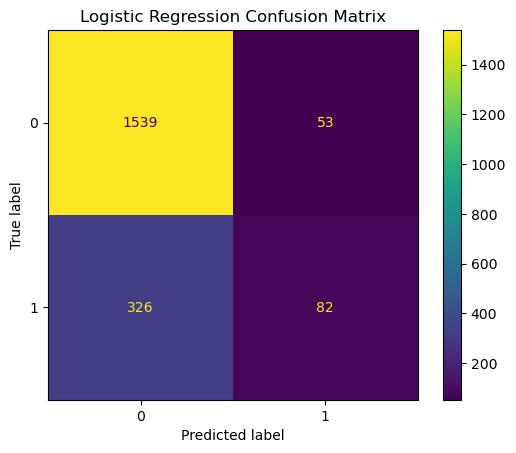

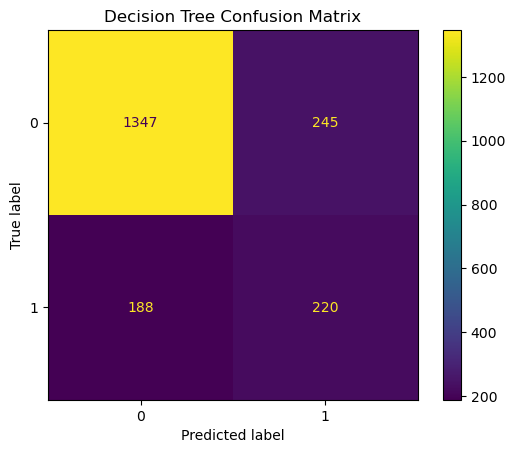

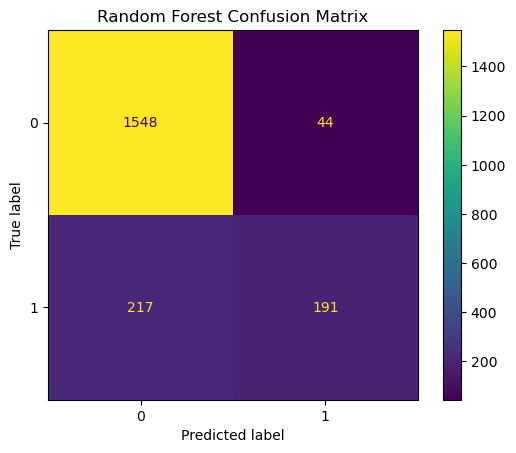

In [125]:
# Visualize Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Logistic Regression
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Decision Tree
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Random Forest
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)   
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

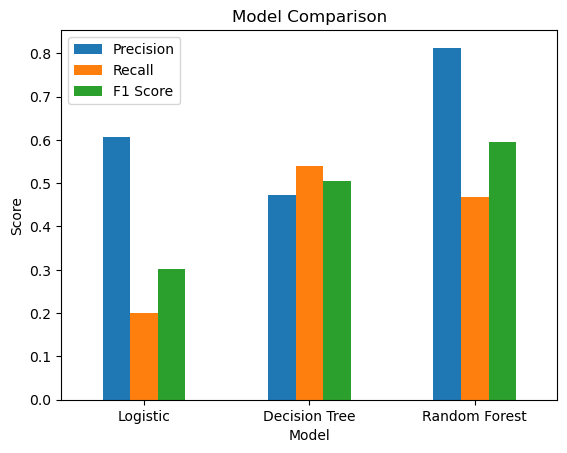

In [126]:
# Visualize Metrics Comparison

metrics = pd.DataFrame({
    "Model": ["Logistic", "Decision Tree", "Random Forest"],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

metrics.set_index("Model").plot(kind="bar")
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

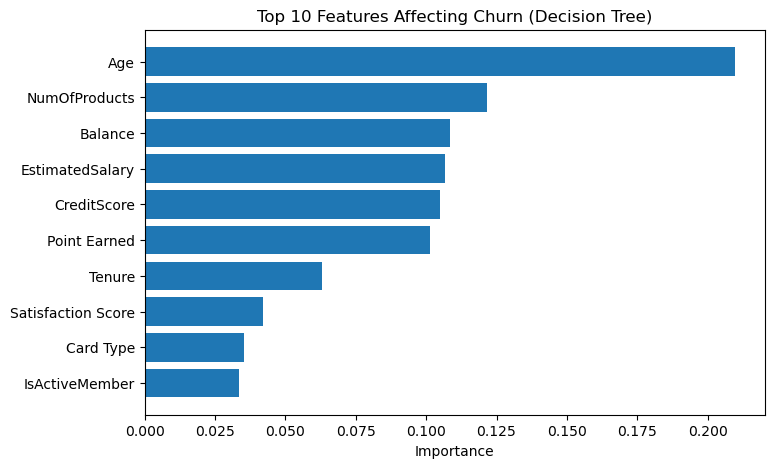

In [129]:
# Vius;alize Feature Importance for Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Features Affecting Churn (Decision Tree)")
plt.xlabel("Importance")
plt.show()

# 📌 Conclusion

This project built a machine learning model to predict customer churn using bank customer data.  
The dataset was clean and required minimal preprocessing, which helped in building reliable models.

---

## 📊 Model Performance

- 🌲 **Random Forest** → Best performance with **86.95% accuracy**  
- 📈 **Logistic Regression** → Stable and consistent results  
- 🌳 **Decision Tree** → Lower accuracy compared to others  

---

## 🔍 Key Insights

- 📌 A few key features strongly influence churn  
- 👤 Customer activity and engagement are critical factors  
- 🔄 Proper encoding of categorical data improves results  
- 🚀 Ensemble models like Random Forest perform better  

---

## 🎯 Final Outcome

The model can effectively identify customers who are likely to leave.  
These insights help businesses take early action to improve retention and reduce churn.